In [1]:
import os, time
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

from redpitaya_control.redpitaya_dev import redpitaya_dev
from redpitaya_control.event_logger import EventLogger, unpack, load_run, fit_clock, counter_to_unix
from redpitaya_control import compute_coeff


import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

from scipy.optimize import curve_fit
from scipy.special import factorial


from pathlib import Path
import matplotlib.pyplot as plt


runfiles = ['time_analysis','time_analysis_new_source_ten_minute']#_ten_minutes'] ##OLD, NEW

MAX_Q15 = 32767 / 32768
C1 = 99.90741625
C2 = 1225.60912165
C3 = 1024.0
C4 = 14.4









In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit



import numpy as np

# Your known calibration points
cal_adu = np.array([450, 1243, 12216])
cal_kev = np.array([6.395, 14.4129, 122.06])

# Calculate the quadratic fit (2nd-degree polynomial)
a, b, c = np.polyfit(cal_adu, cal_kev, deg=2)

# print(f"a = {a:e}")
# print(f"b = {b:e}")
# print(f"c = {c:e}")


def adu_to_kev(adu):

    a = -2.555374e-08
    b = 1.015411e-02
    c = 1.830826e+00
    
    return a * (adu ** 2) + b * adu + c


def kev_to_adu(kev):
    a = -2.555374e-08
    b = 1.015411e-02
    c = 1.830826e+00
    
    # Calculate ADU using the positive root of the quadratic formula
    adu = (-b + np.sqrt(b**2 - 4 * a * (c - kev))) / (2 * a)
    
    return adu



# --- Data Loading ---
raw = load_run(f"{runfiles[0]}/events_*.bin")
ts_us_old, energy_old, _ = unpack(raw)

print(
    f"{len(ts_us_old)} events, span {(ts_us_old[-1]-ts_us_old[0])/1e6:.1f} s"
    if len(ts_us_old) > 1
    else "no events"
)
a, b, ppm = fit_clock(f"{runfiles[0]}/tiepoints.csv")
print(f"Crystal drift: {ppm:+.1f} ppm")
t_unix_old = counter_to_unix(ts_us_old, a, b)


raw = load_run(f"{runfiles[1]}/events_*.bin")
ts_us_new, energy_new, chb = unpack(raw)
print(
    f"{len(ts_us_new)} events, span {(ts_us_new[-1]-ts_us_new[0])/1e6:.1f} s"
    if len(ts_us_new) > 1
    else "no events"
)

a, b, ppm = fit_clock(f"{runfiles[1]}/tiepoints.csv")
print(f"Crystal drift: {ppm:+.1f} ppm")
t_unix_new = counter_to_unix(ts_us_new, a, b)



807516 events, span 599.6 s
Crystal drift: -1.0 ppm
524395 events, span 599.0 s
Crystal drift: +16.0 ppm


[Old Data] Interval timestamps: (5997,)
[Old Data] Found 183835 events in the 13.3-15.5 keV range.
[Old Data] Grouped into 5997 100.0-ms intervals.
[Old Data] Max events in a single interval: 50
[New Data] Interval timestamps: (5990,)
[New Data] Found 210051 events in the 13.3-15.5 keV range.
[New Data] Grouped into 5990 100.0-ms intervals.
[New Data] Max events in a single interval: 59


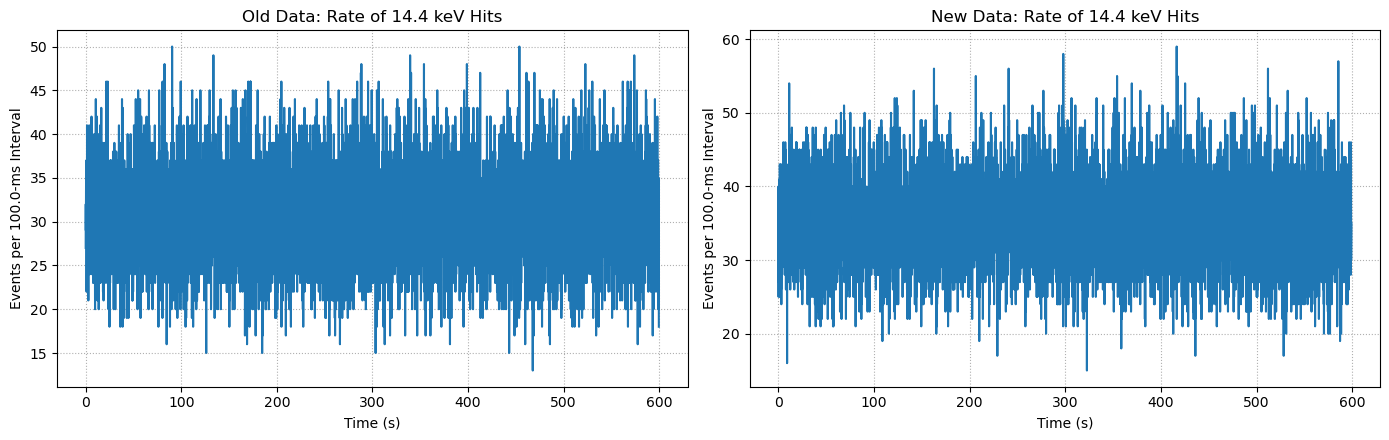

In [5]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np


def graph_rate(e_start=13.3, e_end=15.5, interval_us=100000, file=None, save=False):
    # Select datasets to process
    if file == 1:
        datasets = [(ts_us_old, energy_old, "Old Data")]
    elif file == 2:
        datasets = [(ts_us_new, energy_new, "New Data")]
    elif file is None:
        datasets = [
            (ts_us_old, energy_old, "Old Data"),
            (ts_us_new, energy_new, "New Data"),
        ]
    else:
        raise ValueError("Parameter 'file' must be 1, 2, or None.")

    # Setup subplot layout based on number of datasets
    if len(datasets) == 2:
        fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    else:
        fig, ax = plt.subplots(figsize=(8, 4.5))
        axes = [ax]

    average_kev = np.average([e_start, e_end])
    interval_ms = interval_us / 1000.0

    for idx, (ts_us, energy, file_label) in enumerate(datasets):
        ax = axes[idx]

        energy_kev = adu_to_kev(energy)

        # Filter for the e_start - e_end keV range
        mask = (energy_kev >= e_start) & (energy_kev <= e_end)
        filtered_energies = energy_kev[mask]
        filtered_times_us = ts_us[mask]

        if len(ts_us) > 0 and len(ts_us[ts_us > 0]) > 0:
            start_time = ts_us[ts_us > 0][0]
            end_time = ts_us[-1]

            # Generate bin edges
            time_bins = np.arange(
                start_time, end_time + interval_us, interval_us
            )

            # Calculate the frequency in each interval
            frequencies, _ = np.histogram(filtered_times_us, bins=time_bins)
            interval_timestamps = time_bins[:-1]

            print(
                f"[{file_label}] Interval timestamps: {np.shape(interval_timestamps)}"
            )
            print(
                f"[{file_label}] Found {len(filtered_energies)} events in the {e_start}-{e_end} keV range."
            )
            print(
                f"[{file_label}] Grouped into {len(frequencies)} {interval_ms:.1f}-ms intervals."
            )
            print(
                f"[{file_label}] Max events in a single interval: {np.max(frequencies)}"
            )
        else:
            print(f"[{file_label}] No events to process.")
            interval_timestamps = np.array([])
            frequencies = np.array([])

        timestamps_s = interval_timestamps / 1e6  # Convert us to seconds

        ax.plot(timestamps_s, frequencies)
        ax.set_xlabel("Time (s)")
        ax.set_ylabel(f"Events per {interval_ms:.1f}-ms Interval")
        ax.set_title(f"{file_label}: Rate of {average_kev:.1f} keV Hits")
        ax.grid(True, linestyle=":")

    plt.tight_layout()

    if save:
        base_path = Path(f"rate_{average_kev:.1f}_{file_label}_keV.png")
        stem = base_path.stem
        suffix = base_path.suffix
        parent = base_path.parent

        save_path = base_path
        counter = 1

        while save_path.exists():
            save_path = parent / f"{stem}_{counter}{suffix}"
            counter += 1

        plt.savefig(save_path, transparent=True, bbox_inches="tight")
        print(f"Saved figure to: {save_path}")

    plt.show()


# --- Usage Examples ---

# Option A: Plot both files side-by-side (default)
graph_rate(e_start=13.3, e_end=15.5, interval_us=1e5)

# Option B: Plot a single file by specifying file=1 or file=2
# graph_rate(e_start=13.3, e_end=15.5, interval_us=1e5, file=1)


In [ ]:
# interval_timestamps[:-1]-interval_timestamps[1:]
# time_bins


Average frequency: 15.19 events per 1 s interval.


[File 1] Average frequency: 30.64 events per 0.10 s interval.
[File 2] Average frequency: 35.06 events per 0.10 s interval.


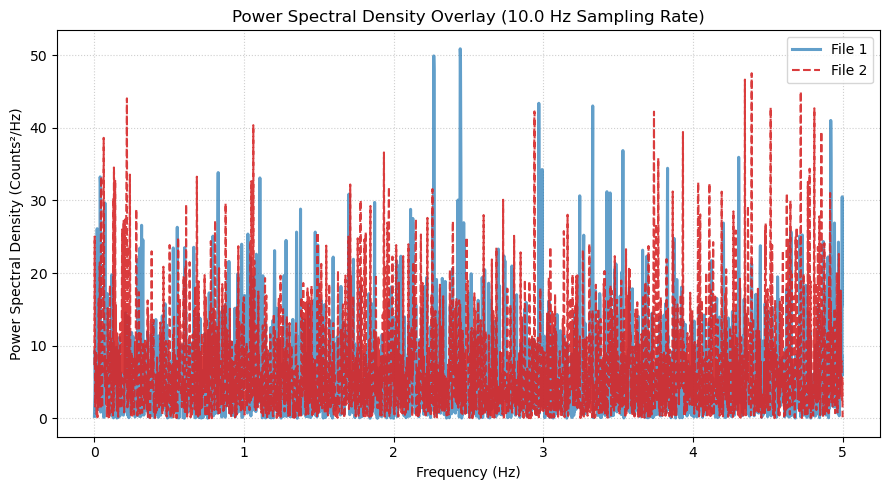

In [14]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal


def graph_psd(
    e_start=13.3,
    e_end=15.5,
    interval_us=100000,
    file=None,
    overlay=False,
    log_scale=False,
    save=False,
):
    # Select datasets to process
    if file == 1:
        datasets = [(ts_us_old, energy_old, "File 1")]
    elif file == 2:
        datasets = [(ts_us_new, energy_new, "File 2")]
    elif file is None:
        datasets = [
            (ts_us_old, energy_old, "File 1"),
            (ts_us_new, energy_new, "File 2"),
        ]
    else:
        raise ValueError("Parameter 'file' must be 1, 2, or None.")

    # Configure plot axes
    if overlay or len(datasets) == 1:
        fig, ax = plt.subplots(figsize=(9, 5))
        axes = [ax] * len(datasets)
    else:
        fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

    average_kev = np.average([e_start, e_end])
    fs = 1e6 / interval_us

    # Plot styling to easily distinguish overlaps
    plot_styles = [
        {
            "color": "tab:blue",
            "linestyle": "-",
            "linewidth": 2.2,
            "alpha": 0.7,
        },  # File 1: Thick Solid
        {
            "color": "tab:red",
            "linestyle": "--",
            "linewidth": 1.5,
            "alpha": 0.9,
        },  # File 2: Thin Dashed
    ]

    for idx, (ts_us, energy, file_label) in enumerate(datasets):
        ax = axes[idx]
        style = plot_styles[idx] if overlay else {}

        energy_kev = adu_to_kev(energy)
        mask = (energy_kev >= e_start) & (energy_kev <= e_end)
        filtered_times_us = ts_us[mask]

        if len(ts_us) > 0 and len(ts_us[ts_us > 0]) > 0:
            start_time = ts_us[ts_us > 0][0]
            end_time = ts_us[-1]
            time_bins = np.arange(
                start_time, end_time + interval_us, interval_us
            )
            frequencies, _ = np.histogram(filtered_times_us, bins=time_bins)
        else:
            frequencies = np.array([])

        if len(frequencies) > 0:
            average_frequency = np.mean(frequencies)
            interval_s = interval_us / 1e6
            print(
                f"[{file_label}] Average frequency: {average_frequency:.2f} events per {interval_s:.2f} s interval."
            )

            # Compute Welch PSD
            requested_nperseg = int(fs / 1e-3)
            nperseg_full = min(requested_nperseg, len(frequencies))

            f_full, psd_full = signal.welch(
                frequencies, fs=fs, nperseg=nperseg_full
            )

            label = file_label if overlay else "Full Trace"
            ax.plot(f_full, psd_full, label=label, **style)
            ax.legend()
        else:
            print(f"[{file_label}] No events to compute PSD.")

        ax.set_xlabel("Frequency (Hz)")
        ax.set_ylabel("Power Spectral Density (Counts²/Hz)")

        if log_scale:
            ax.set_yscale("log")

        if not overlay:
            ax.set_title(
                f"{file_label}: Power Spectral Density ({fs:.1f} Hz Sampling Rate)"
            )
            ax.grid(True, which="both", linestyle=":", alpha=0.6)

    if overlay:
        axes[0].set_title(
            f"Power Spectral Density Overlay ({fs:.1f} Hz Sampling Rate)"
        )
        axes[0].grid(True, which="both", linestyle=":", alpha=0.6)

    plt.tight_layout()

    if save:
        base_path = Path(f"fourier_{average_kev:.1f}keV.png")
        stem = base_path.stem
        suffix = base_path.suffix
        parent = base_path.parent

        save_path = base_path
        counter = 1

        while save_path.exists():
            save_path = parent / f"{stem}_{counter}{suffix}"
            counter += 1

        plt.savefig(save_path, transparent=True, bbox_inches="tight")
        print(f"Saved figure to: {save_path}")

    plt.show()


# Example usage:
graph_psd(e_start=13.3, e_end=15.5, interval_us=1e5, overlay=True)


In [190]:
f[1]

np.float64(0.001)

Text(0.5, 1.0, 'Serial Correlation Check (Lags 1-20)')

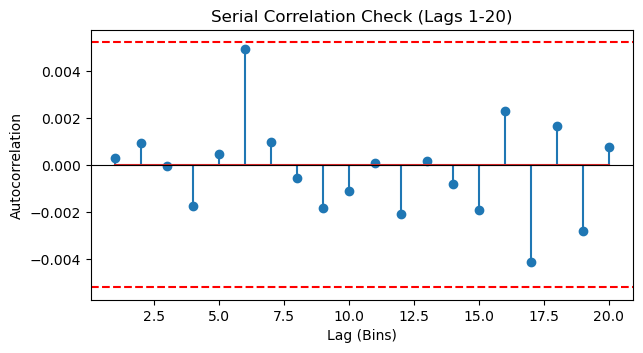

In [168]:
# Normalized autocorrelation of count fluctuations
counts_centered = frequencies - np.mean(frequencies)
autocorr = np.correlate(counts_centered, counts_centered, mode='full')
autocorr = autocorr[
    len(frequencies) - 1 :
] / (  # Keep non-negative lags
    len(frequencies) * np.var(frequencies)
)

plt.figure(figsize=(7, 3.5))
plt.stem(
    range(1, 21), autocorr[1:21]
)  # Plot first 20 lags (excluding lag 0 which is 1.0)
plt.axhline(0, color='black', linewidth=0.8)
plt.axhline(1.96 / np.sqrt(len(frequencies)), color='r', linestyle='--')
plt.axhline(-1.96 / np.sqrt(len(frequencies)), color='r', linestyle='--')
plt.xlabel('Lag (Bins)')
plt.ylabel('Autocorrelation')
plt.title('Serial Correlation Check (Lags 1-20)')


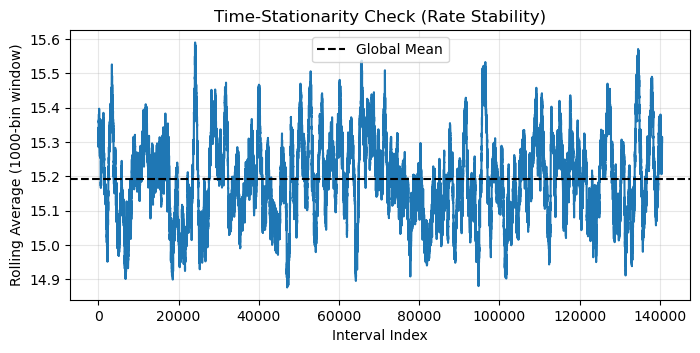

In [172]:
# Compute rolling mean over a moving window of 100 time bins
window_size = 1000
rolling_mean = np.convolve(
    frequencies, np.ones(window_size) / window_size, mode='valid'
)

plt.figure(figsize=(8, 3.5))
plt.plot(rolling_mean, linewidth=1.5)
plt.axhline(np.mean(frequencies), color='black', linestyle='--', label='Global Mean')
plt.xlabel('Interval Index')
plt.ylabel(f'Rolling Average ({window_size}-bin window)')
plt.title('Time-Stationarity Check (Rate Stability)')
plt.legend()
plt.grid(True, alpha=0.3)


(0.1, 0.11)

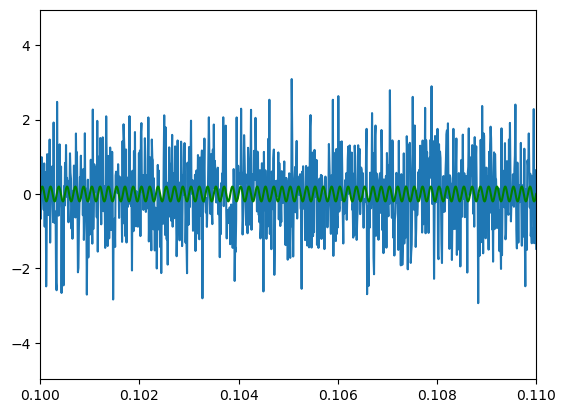

In [166]:
total_time = 10  # seconds
sampling_rate = 100000  # Hz

noise = np.random.normal(scale=1, size=int(total_time * sampling_rate)  )
frequency = 1000  # Frequency of the sine wave in Hz
axion = 0.1*np.sin(np.linspace(0, 20, int(total_time * sampling_rate))*2*np.pi*frequency)
axion2 = 0.2*np.sin(np.linspace(0, 20, int(total_time * sampling_rate))*2*np.pi*frequency*3)

measurement = axion + axion2 + noise
t = np.linspace(0, total_time, int(total_time * sampling_rate))
plt.plot(t, measurement)
# plt.plot(t, axion, color='orange', label='Axion Signal')
plt.plot(t, axion2, color='green', label='Axion Signal 2')
plt.xlim(0.1,0.11)


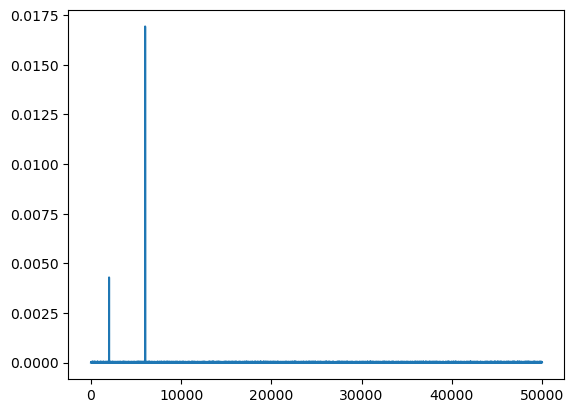

In [158]:
# f, psd_noise = signal.welch(noise, fs=sampling_rate, nperseg = len(measurement)//8)
f, psd = signal.welch(measurement, fs=sampling_rate, nperseg = len(measurement)//8)


plt.plot(f, psd)
#plt.plot(f, psd_noise)